In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from pylab import rcParams
import matplotlib.pyplot as plt
#from google.colab import drive


In [2]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # list_labels_cat = ['ARTEFACTS', 'BLASTES', 'ERYTHROBLASTES', 'LYMPHOCYTES', 'MONOCYTES', 'MYELOCYTES', 'NEUTROPHILES']
    list_labels_cat = ['ARTEFACTS', 'BASOPHILES', 'BLASTES', 'EOSINOPHILES',
       'ERYTHROBLASTES', 'LYMPHOCYTES', 'METAMYELOCYTES', 'MONOCYTES',
       'MYELOCYTES', 'NEUTROPHILES', 'PROMYELOCYTES']
    # init figure size
    # targ_valids_cat = [list_labels_cat[i] for i in target]
    # preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(target, prediction, labels = list_labels_cat, normalize = 'true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')


# Import features

In [3]:
#drive.mount('/content/drive')
#!ls

In [4]:
features_table = pd.read_csv('features_table_renamed_features.csv')
len(features_table.columns)

42

In [5]:
features_table.head()

,Unnamed: 0,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Min_cytoonly,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly
0,0,837,0.3095,0.0945,0.0600,0.6984,0.3025,0.2581,0.1013,0.0578,...,-0.0108,0.9250,0.2995,0.0803,0.1068,0.0,0.9489,0.0335,0.0275,580.8835
1,1,447,0.3790,0.1280,0.0738,0.8538,0.3595,0.3362,0.2064,0.0346,...,0.0053,1.5916,0.3480,0.2224,0.0871,0.0,1.0000,0.2375,0.1405,336.1428
2,2,435,0.4304,0.1727,0.0384,1.0462,0.4145,0.4348,0.3306,0.0145,...,-0.0075,1.6237,0.3540,0.2508,0.0988,0.0,1.0000,0.2455,0.1545,295.5429
3,3,737,0.3011,0.1867,0.0271,1.3582,0.2535,0.2454,0.2487,-0.0462,...,-0.0287,1.6220,0.3327,0.3251,0.1391,0.0,1.0000,0.2905,0.1805,176.0093
4,4,176,0.3344,0.1360,0.0294,0.8590,0.3345,0.3085,0.1938,0.0077,...,-0.0013,0.6878,0.3425,0.2027,0.0729,0.0,0.8716,0.2135,0.0965,264.4129


# Find null values

1) List the number of null values for each column. Which column has null values?


2) Delete the rows where there are null values


In [6]:
List_valeurs_nulles = []
for column in features_table.columns:
    List_valeurs_nulles.append(int(features_table[column].isnull().sum()))
print(List_valeurs_nulles)

features_table_cleaned = features_table.dropna()
print(features_table.shape)
print(features_table_cleaned.shape)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 29, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(3139, 42)
(3110, 42)


# Add labels

In [7]:
labels = pd.read_csv('labels.csv')
labels

,Unnamed: 0,cytoID,label
0,0,628,NEUTROPHILES
1,1,468,NEUTROPHILES
2,2,55,NEUTROPHILES
3,3,464,NEUTROPHILES
4,4,541,BLASTES
...,...,...,...
3135,2012,2561,LYMPHOCYTES
3136,2013,2829,ERYTHROBLASTES
3137,2014,2591,NEUTROPHILES
3138,2015,2849,ERYTHROBLASTES


3) We want to remove the labels of the cells deleted in the previous question. To do so, create a new dataframe "*dataset*" generated by the joint of *features_table* and *labels* on **cytoID** number.

In [8]:
dataset = pd.merge(features_table_cleaned, labels, on='cytoID')

# Visualise the distribution of the class



4) Count the number of cells per class. What can we say about the distribution of the classes?

5) Plot the distribution of the classes using sns.countplot() and the dataframe.

*Expected result*

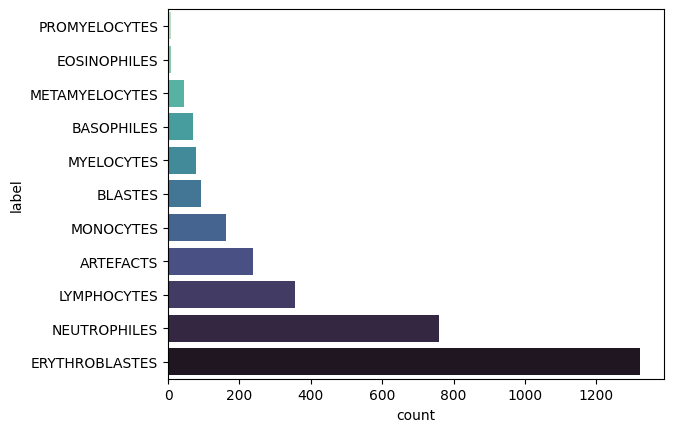

The distribution is pretty unbalanced : the ERYTHROBLASTES is way more important than many other class in the dataset

In [9]:
Distribution = dataset['label'].value_counts()
Distribution = Distribution.iloc[::-1]
print(Distribution)


label
PROMYELOCYTES        6
EOSINOPHILES         7
METAMYELOCYTES      44
BASOPHILES          68
MYELOCYTES          77
BLASTES             91
MONOCYTES          160
ARTEFACTS          231
LYMPHOCYTES        357
NEUTROPHILES       749
ERYTHROBLASTES    1320
Name: count, dtype: int64


/var/folders/wh/n9fzjkv520d9f1c4gxhh1y7c0000gn/T/ipykernel_74515/1983335577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(dataset['label'], order = Distribution.index, palette = "viridis")


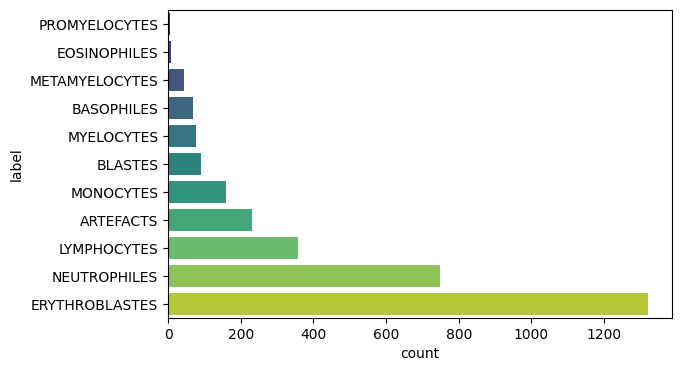

In [10]:
plt.figure(figsize = (6.5, 4))
sns.countplot(dataset['label'], order = Distribution.index, palette = "viridis") 
plt.show()

# Visualise features

We can use .describe() to visualise the behaviour of each feature.

In [11]:
dataset.describe()

,Unnamed: 0_x,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly,Unnamed: 0_y
count,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,...,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000
mean,850.220900,1574.875241,0.863911,0.242266,0.151510,1.767968,0.864445,0.226423,0.237001,-0.271824,...,0.975739,0.241823,0.258577,0.148072,0.022247,0.895672,0.227580,0.044030,51.556067,847.837299
std,548.072579,906.189013,0.641885,0.162756,0.139328,1.195020,0.647994,0.166961,0.120402,0.459606,...,0.522370,0.059630,0.101322,0.063019,0.033845,0.168434,0.095092,0.046182,55.102101,549.702719
min,0.000000,1.000000,0.136200,0.033600,-0.049300,0.276500,0.073500,-0.734400,0.011200,-1.943500,...,-0.026800,0.131100,0.044500,0.029800,0.000000,0.233300,0.021500,0.000000,0.511500,0.000000
25%,394.250000,790.250000,0.354775,0.117500,0.047750,0.861900,0.344500,0.122150,0.131950,-0.261100,...,0.454475,0.189450,0.189400,0.098900,0.000000,0.841075,0.165750,0.000000,12.195700,391.000000
50%,787.000000,1577.500000,0.577000,0.186700,0.105150,1.273900,0.559500,0.221650,0.239900,-0.083050,...,1.119400,0.239900,0.237550,0.134550,0.008500,1.000000,0.212500,0.033500,26.240350,783.500000
75%,1233.750000,2358.750000,1.258450,0.324700,0.218575,2.319775,1.299250,0.315475,0.332725,0.002475,...,1.395700,0.297050,0.311675,0.188175,0.028450,1.000000,0.273500,0.075500,79.882625,1234.750000
max,2015.000000,3140.000000,3.193700,0.996000,1.147000,4.278200,3.139500,0.911500,0.684200,0.179200,...,3.855600,0.477700,0.791600,0.367300,0.328700,1.000000,0.962500,0.692500,580.883500,2016.000000


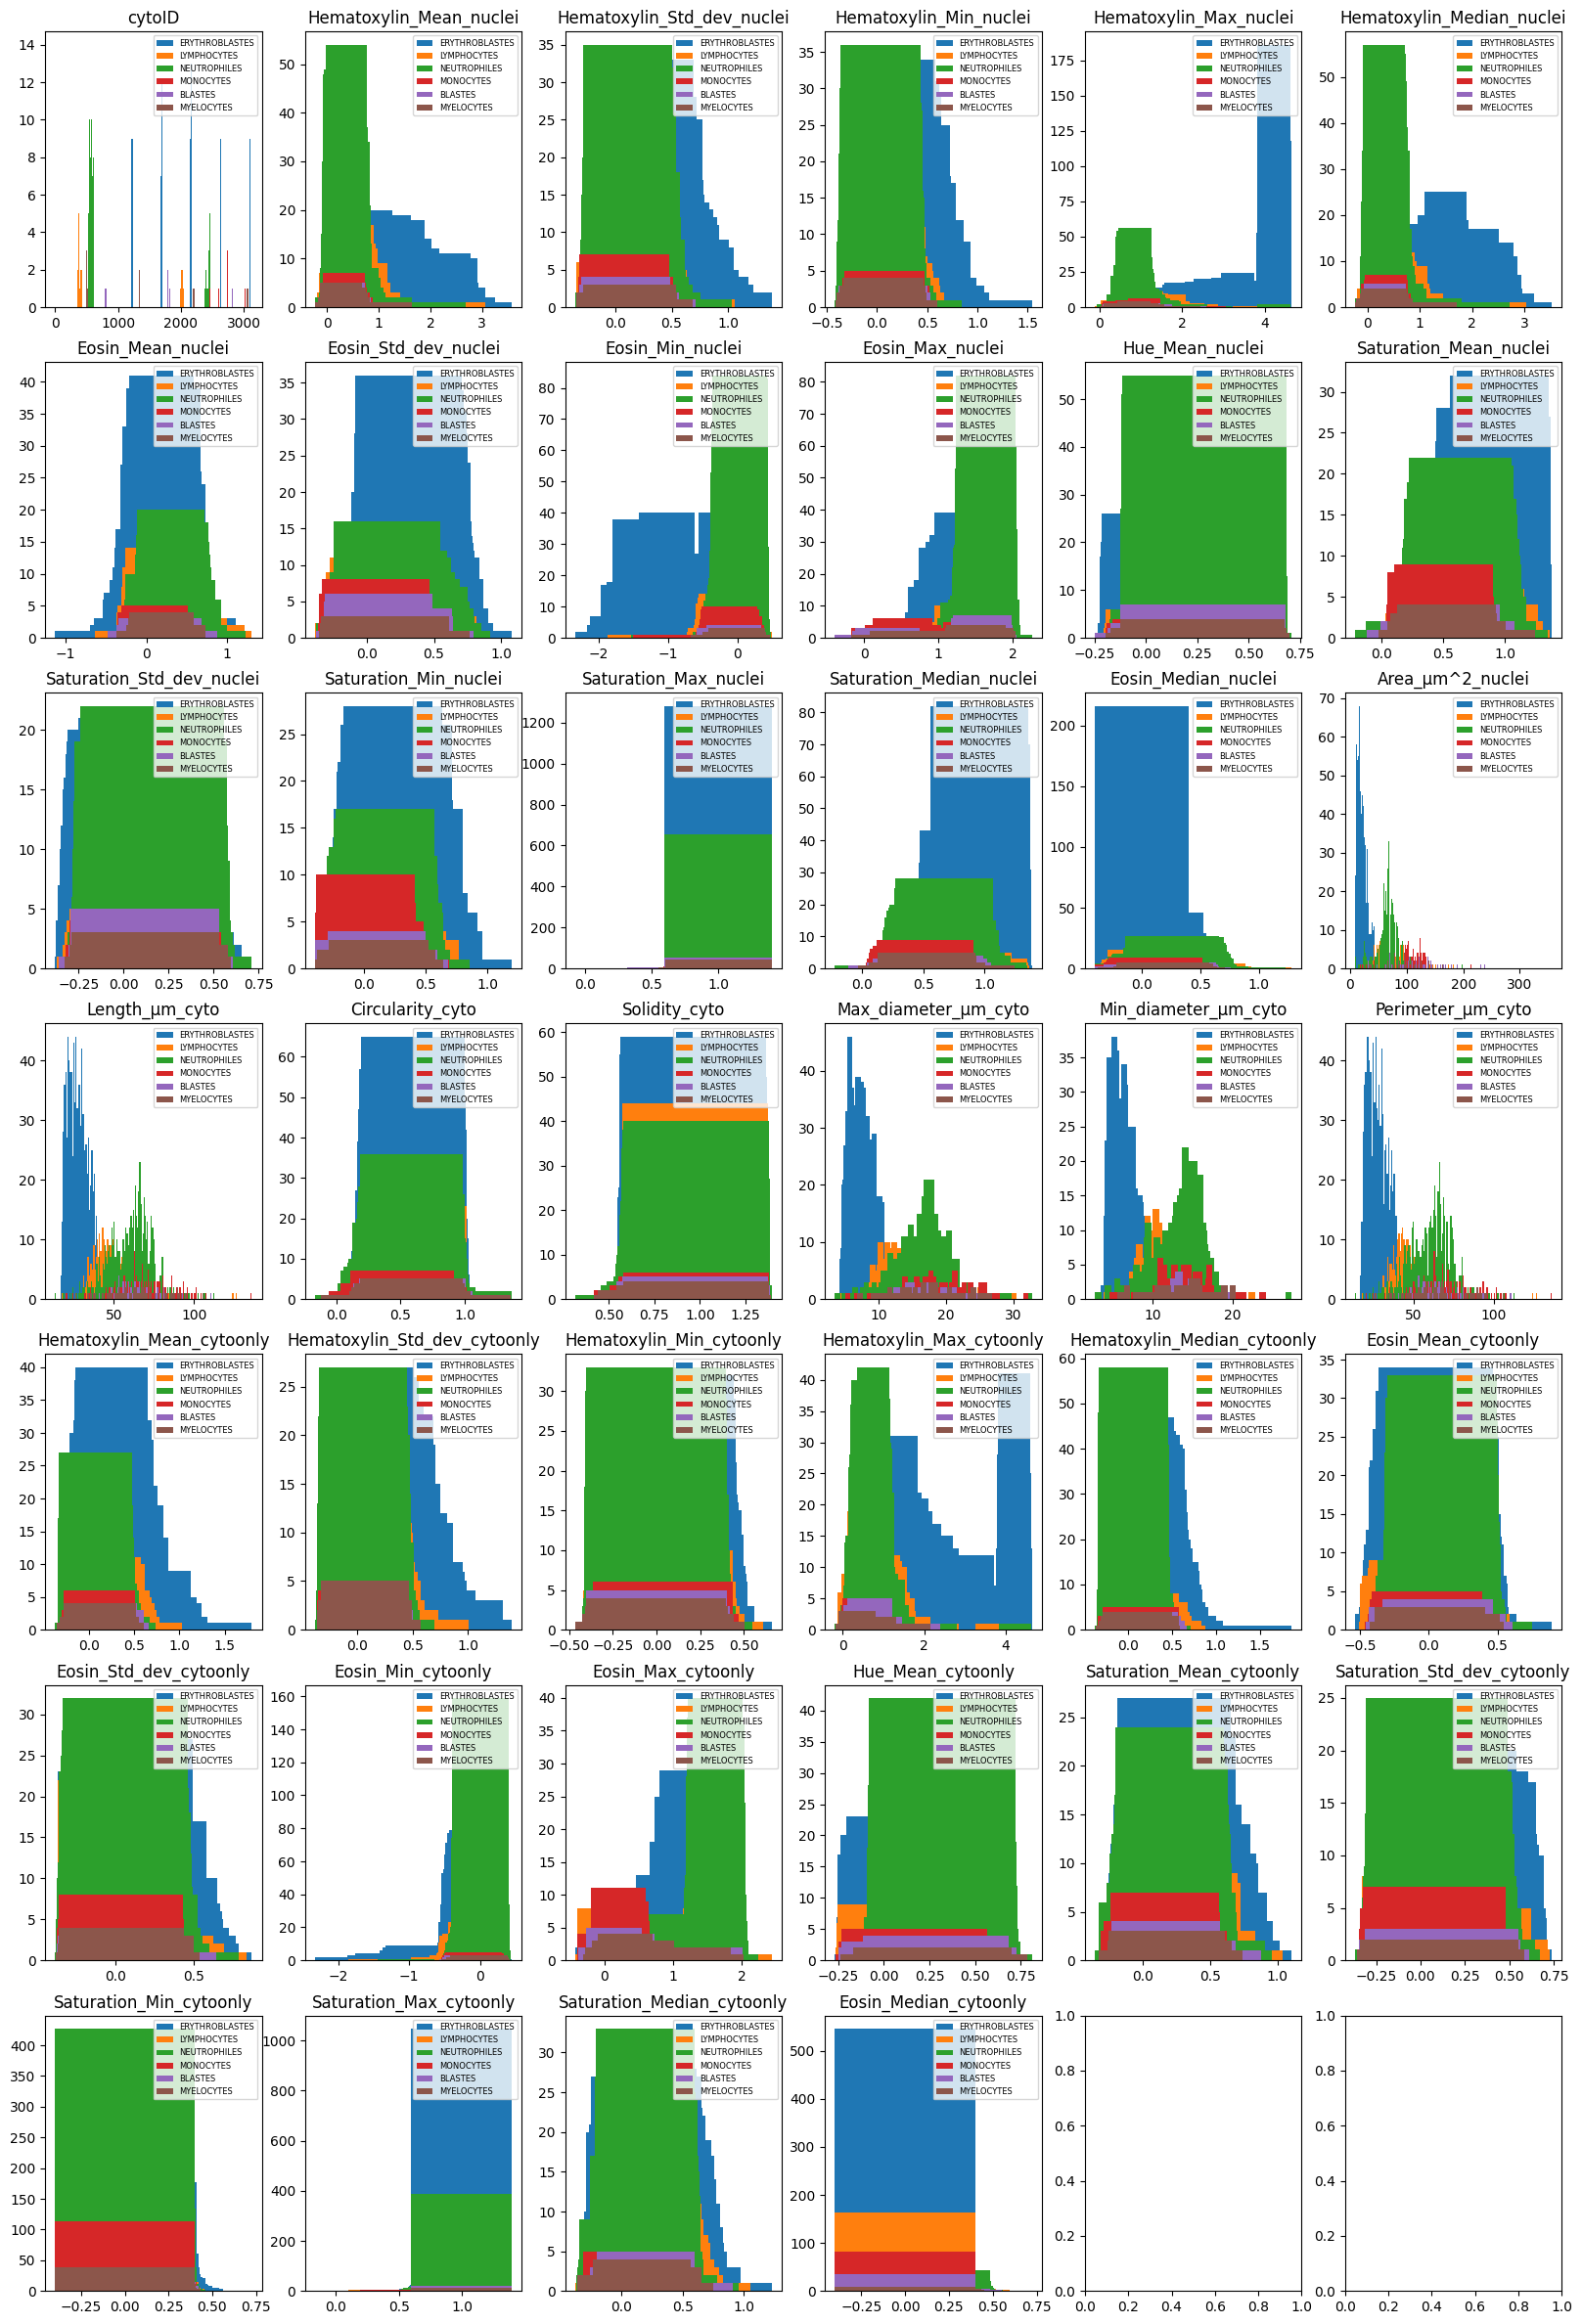

In [12]:
rcParams['figure.figsize'] = 20, 30
fig, axes = plt.subplots(7,6)

for i, ax in enumerate(axes.flat, start=1):
    if i < 41:
        y_max = 0
        for k in ['ERYTHROBLASTES', 'LYMPHOCYTES','NEUTROPHILES', 'MONOCYTES',  'BLASTES', 'MYELOCYTES']:

            sub_df = dataset.loc[dataset.label == k]

            sub_df =sub_df.drop('label', axis = 1)
            a_heights, a_bins = np.histogram(np.array(sub_df[dataset.columns[i]], dtype=float), bins=200)
            if max(a_heights) + max(a_heights)*0.05 > y_max:
                y_max = max(a_heights) + max(a_heights)*0.05

            ax.bar(a_bins[:-1], a_heights, label = k)
            ax.legend(loc="upper right", prop={'size': 6})
            ax.set_ylim((0, y_max))
            ax.set_xlabel = ('Feature value')
            ax.set_ylabel = ('Number of cells')
            ax.set_title(dataset.columns[i])


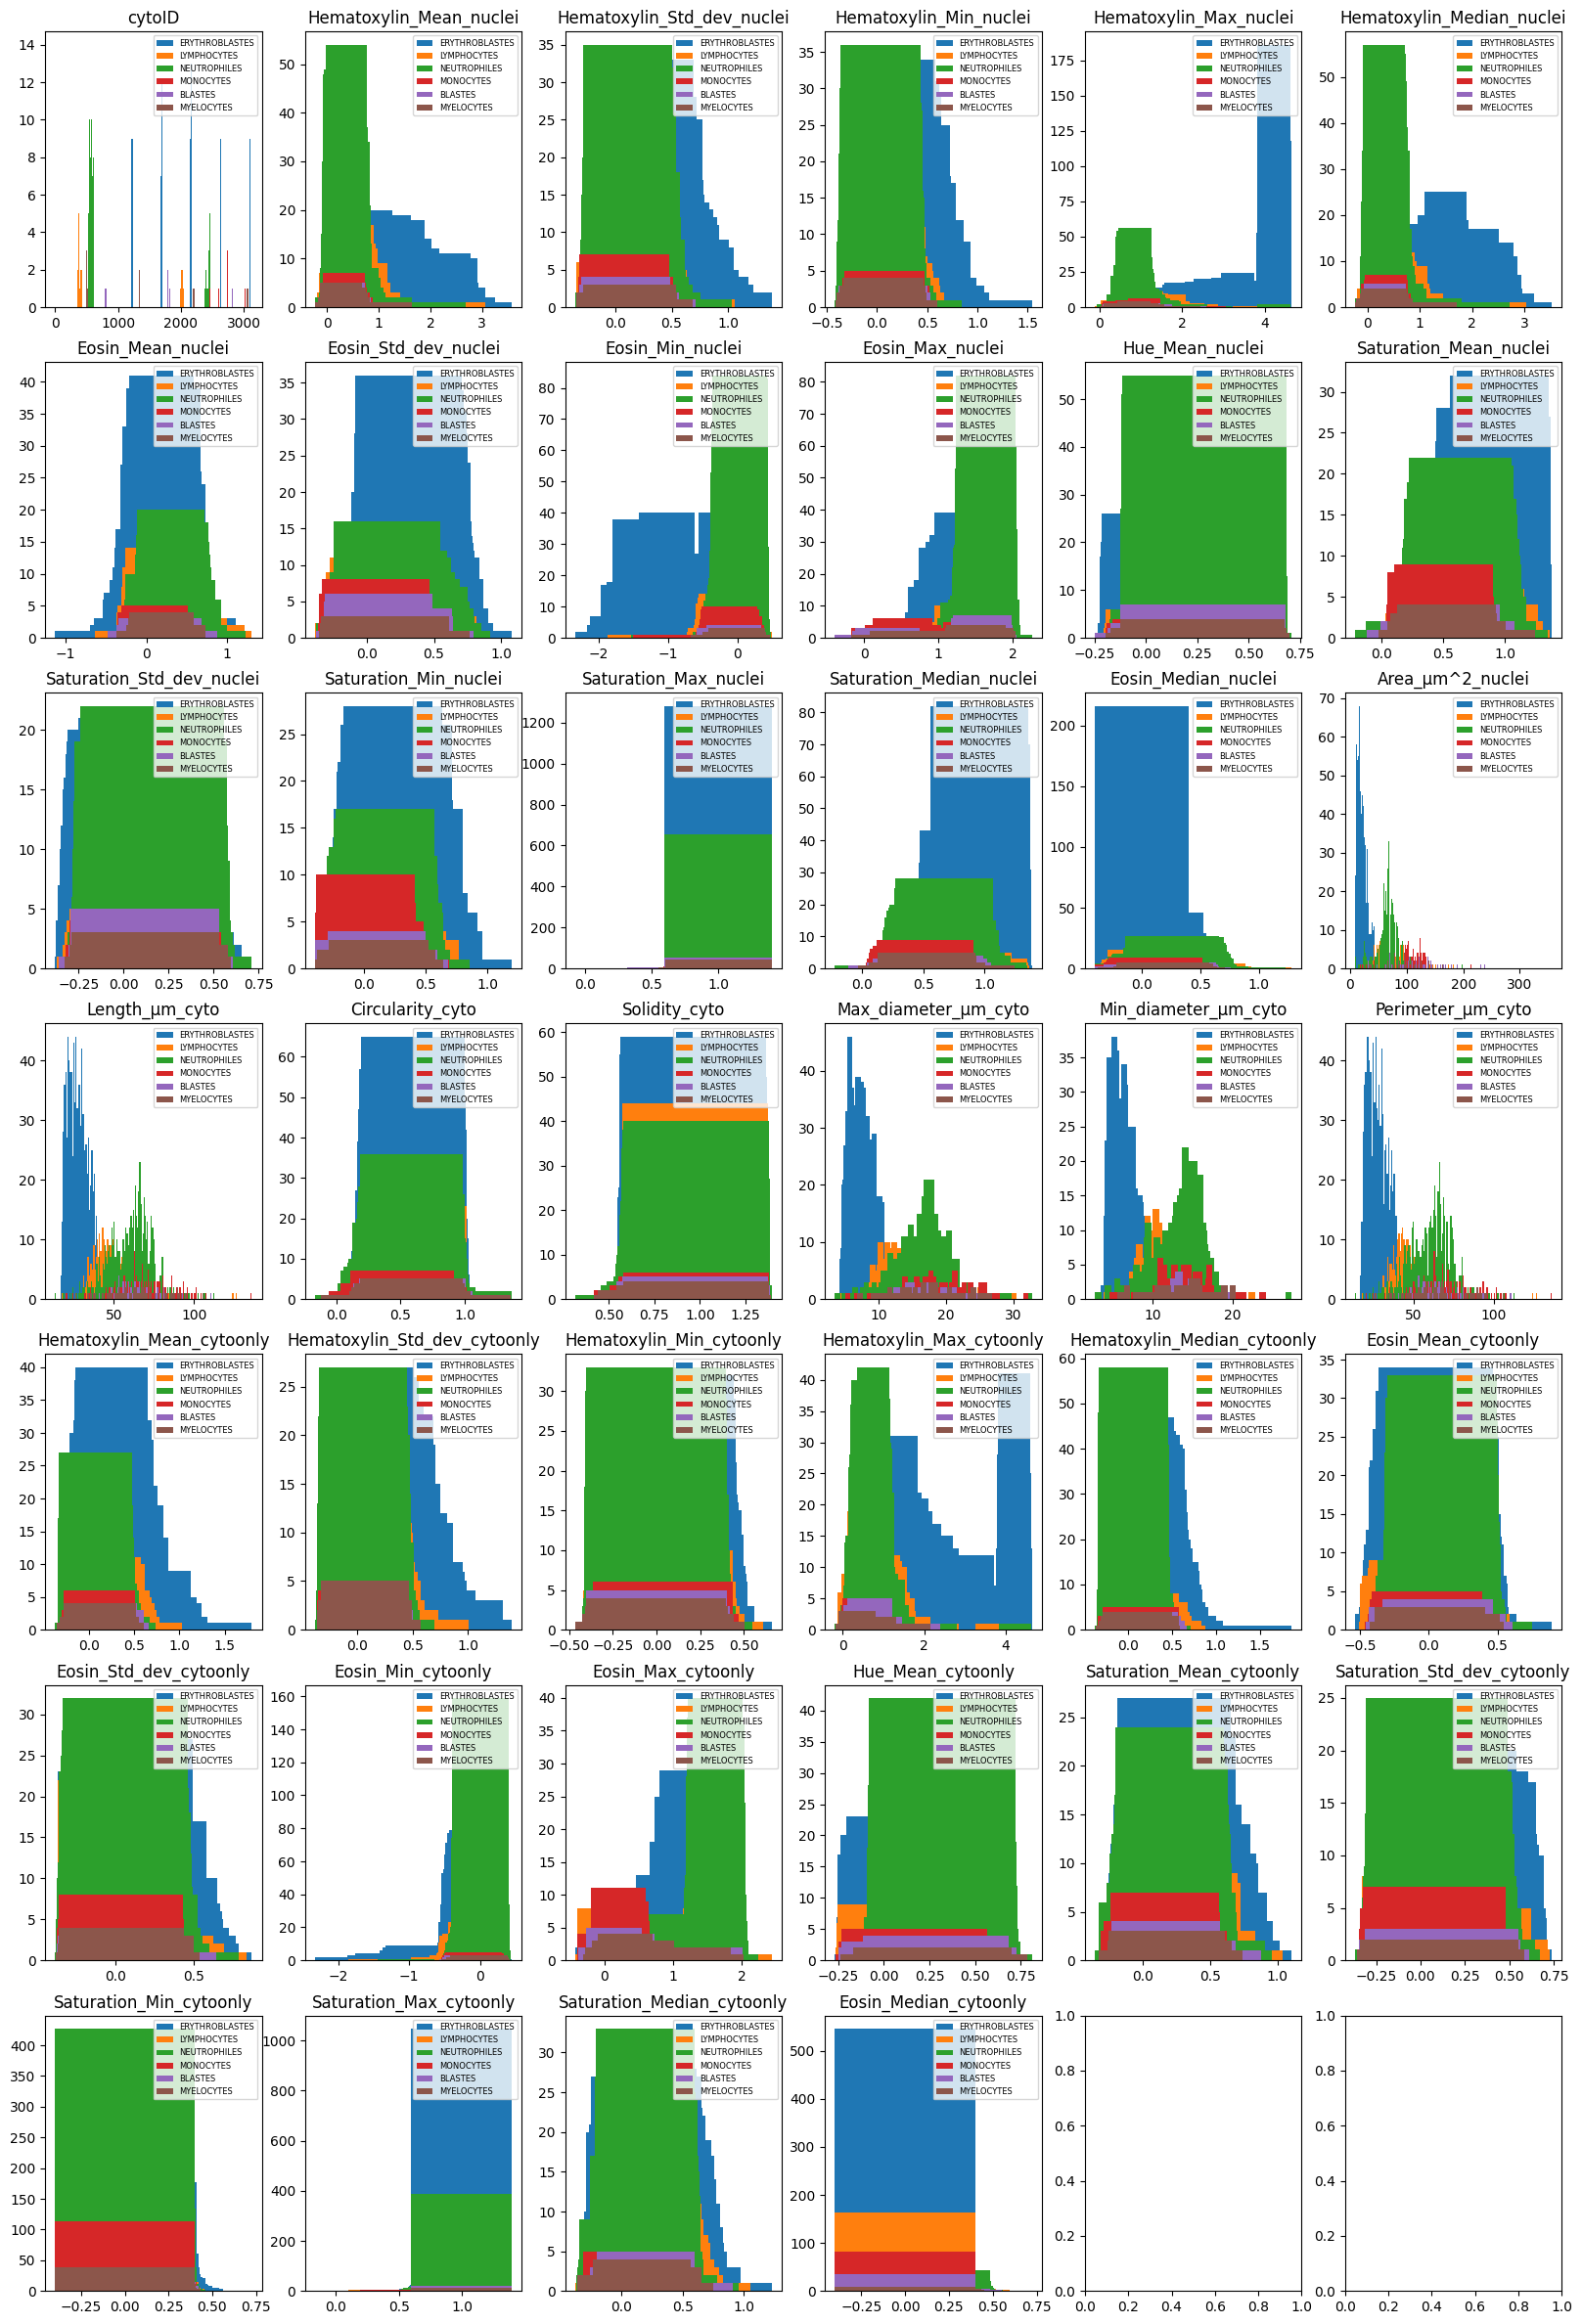

6) The above figure represents the distribution of cells according to features.

Which features do you think are the most discriminative for determining cell class? Explain.

The most discriminative features are the ones for which the distributions of every cell class are distinct. We don't have a feature that perfectly discriminates the class however the geometrical features (especially min and max diameter, perimeter, length but also the area feature) give the best separtations between classes according to the above figure.

7) a) Using scatter_matrix(), represent the correlation between 6 geometrical features.

b) Do the same for 6 colour features (preferably different colour features, ex: Eosin, Hematoxylin, Hue...)

*Expected result*

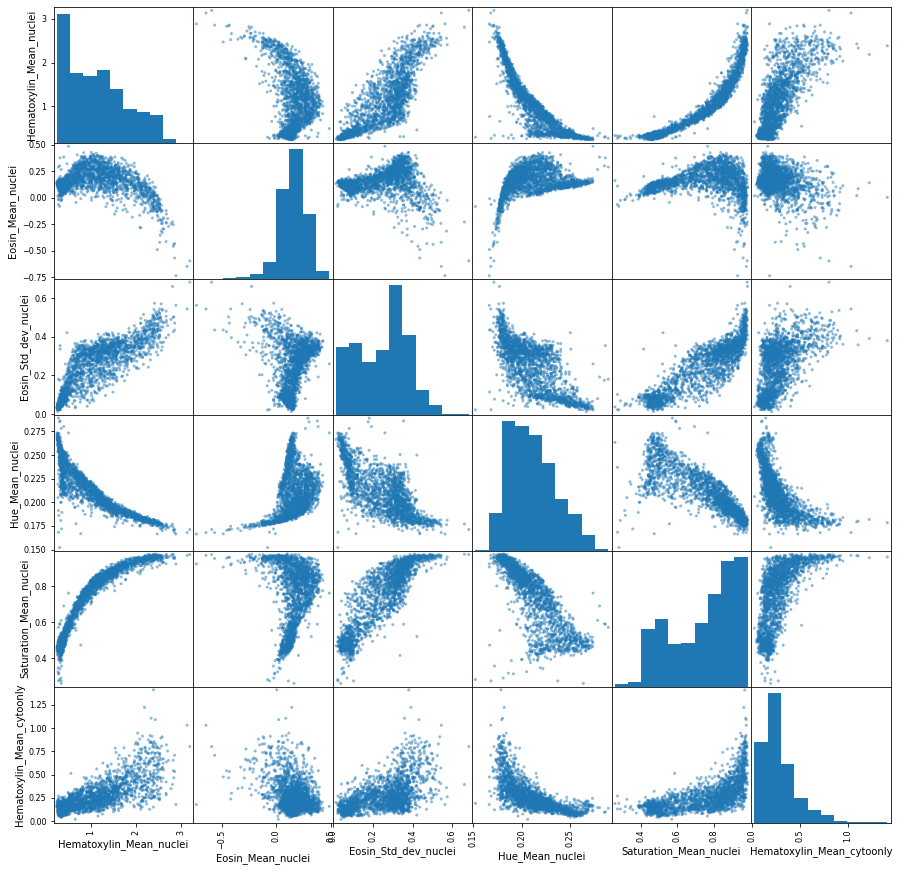


In [13]:
print(dataset.columns)

Index(['Unnamed: 0_x', 'cytoID', 'Hematoxylin_Mean_nuclei',
       'Hematoxylin_Std_dev_nuclei', 'Hematoxylin_Min_nuclei',
       'Hematoxylin_Max_nuclei', 'Hematoxylin_Median_nuclei',
       'Eosin_Mean_nuclei', 'Eosin_Std_dev_nuclei', 'Eosin_Min_nuclei',
       'Eosin_Max_nuclei', 'Hue_Mean_nuclei', 'Saturation_Mean_nuclei',
       'Saturation_Std_dev_nuclei', 'Saturation_Min_nuclei',
       'Saturation_Max_nuclei', 'Saturation_Median_nuclei',
       'Eosin_Median_nuclei', 'Area_µm^2_nuclei', 'Length_µm_cyto',
       'Circularity_cyto', 'Solidity_cyto', 'Max_diameter_µm_cyto',
       'Min_diameter_µm_cyto', 'Perimeter_µm_cyto',
       'Hematoxylin_Mean_cytoonly', 'Hematoxylin_Std_dev_cytoonly',
       'Hematoxylin_Min_cytoonly', 'Hematoxylin_Max_cytoonly',
       'Hematoxylin_Median_cytoonly', 'Eosin_Mean_cytoonly',
       'Eosin_Std_dev_cytoonly', 'Eosin_Min_cytoonly', 'Eosin_Max_cytoonly',
       'Hue_Mean_cytoonly', 'Saturation_Mean_cytoonly',
       'Saturation_Std_dev_cytoonly',

<Figure size 2000x3000 with 0 Axes>

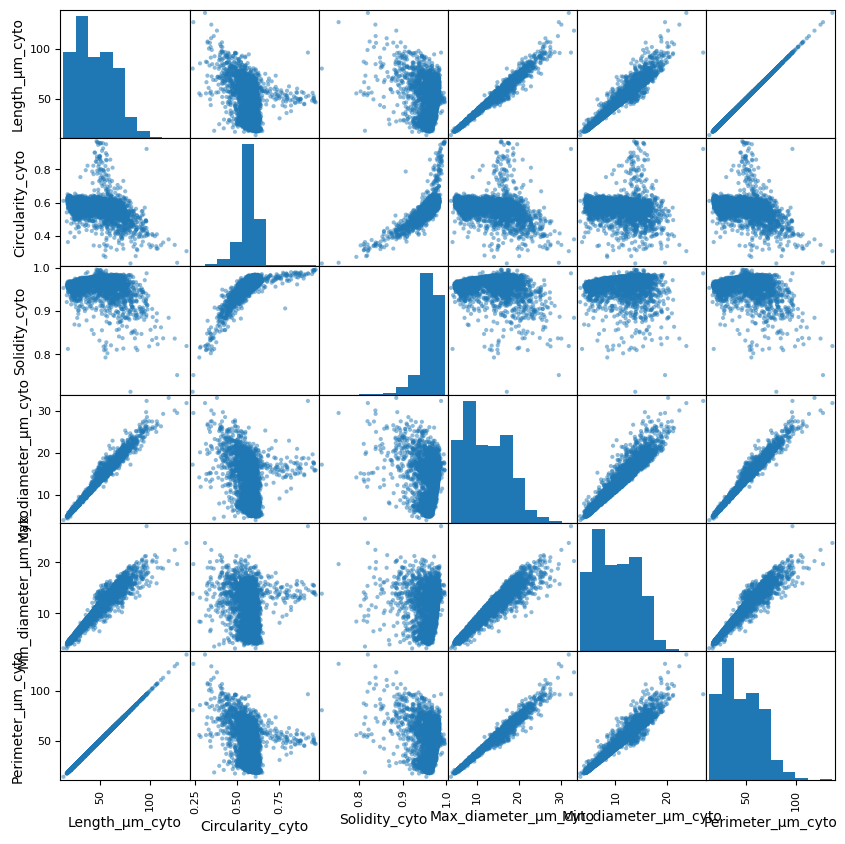

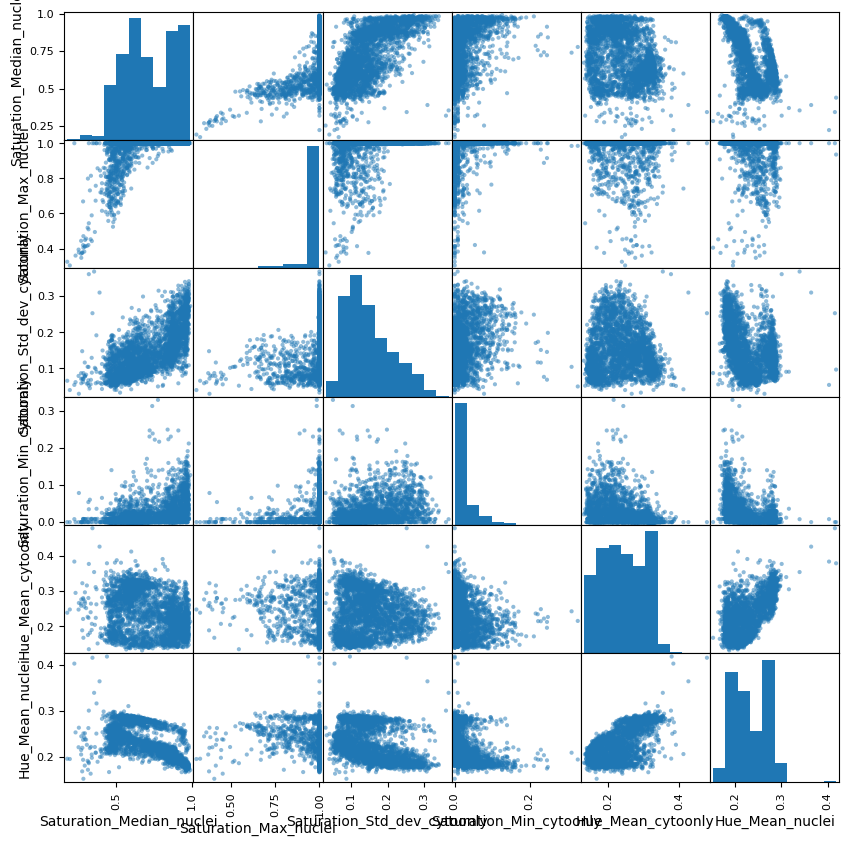

In [14]:
Geometrical_features = ['Length_µm_cyto', 'Circularity_cyto', 'Solidity_cyto', 'Max_diameter_µm_cyto', 'Min_diameter_µm_cyto', 'Perimeter_µm_cyto']
Color_features = ['Saturation_Median_nuclei','Saturation_Max_nuclei', 'Saturation_Std_dev_cytoonly', 'Saturation_Min_cytoonly', 'Hue_Mean_cytoonly', 'Hue_Mean_nuclei']
dataset_geometrical = dataset[Geometrical_features]
dataset_color = dataset[Color_features]
plt.figure()
scatter_matrix(dataset_geometrical, figsize=(10, 10))
scatter_matrix(dataset_color, figsize=(10, 10))
plt.show()

8) Represent the repartition of cells by class for two of the most discriminative features, using sns.boxplot.


*Expected result for a random selected feature*

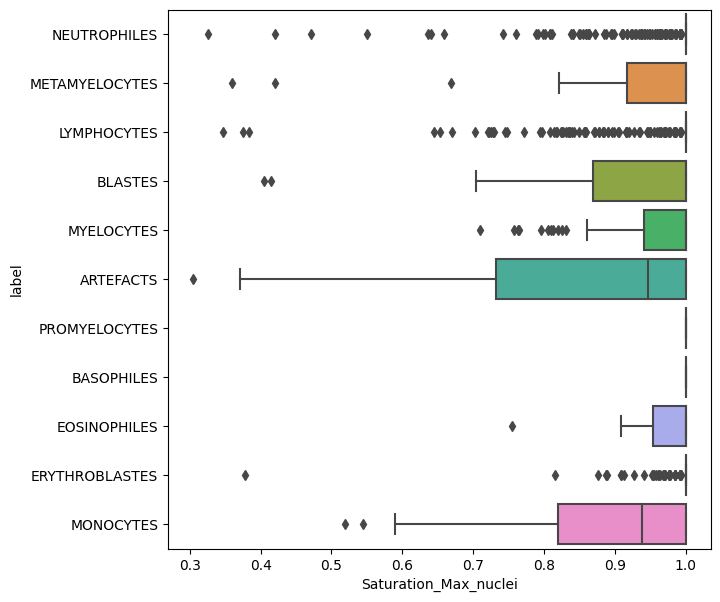

/var/folders/wh/n9fzjkv520d9f1c4gxhh1y7c0000gn/T/ipykernel_74515/3561633668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Max_diameter_µm_cyto', y = 'label', data = dataset, palette = 'viridis')


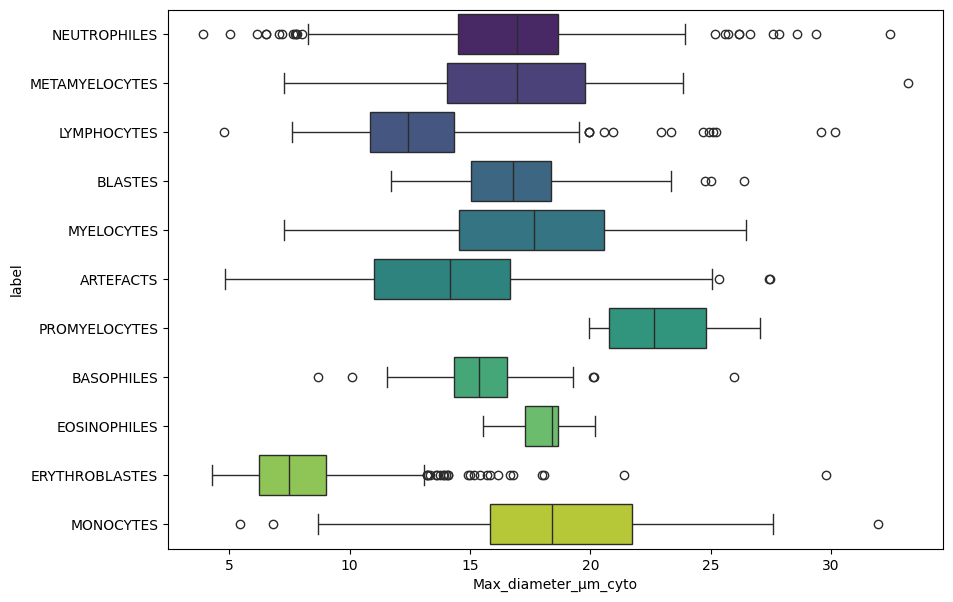

/var/folders/wh/n9fzjkv520d9f1c4gxhh1y7c0000gn/T/ipykernel_74515/3561633668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Perimeter_µm_cyto', y = 'label', data = dataset, palette = 'viridis')


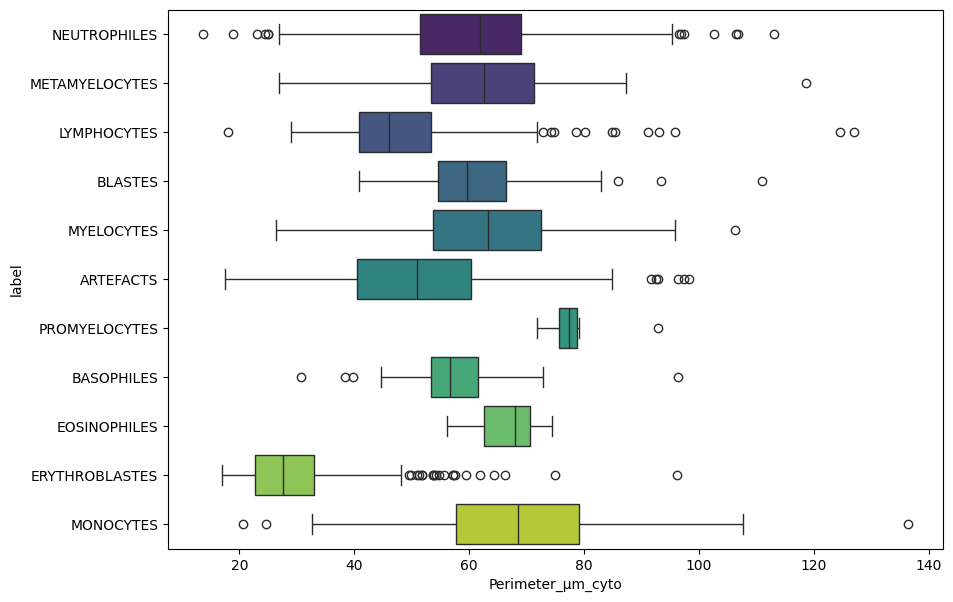

In [15]:
plt.figure(figsize = (10, 7))
sns.boxplot(x = 'Max_diameter_µm_cyto', y = 'label', data = dataset, palette = 'viridis')
plt.show()
plt.figure(figsize = (10, 7))
sns.boxplot(x = 'Perimeter_µm_cyto', y = 'label', data = dataset, palette = 'viridis')
plt.show()

# Create X and y



In [95]:
X = dataset.drop(['cytoID', 'label'], axis=1)
len(X)
y = dataset[['label']]
y

,label
0,NEUTROPHILES
1,METAMYELOCYTES
2,NEUTROPHILES
3,LYMPHOCYTES
4,NEUTROPHILES
...,...
3105,ERYTHROBLASTES
3106,ERYTHROBLASTES
3107,ERYTHROBLASTES
3108,ERYTHROBLASTES


# Splitting the dataset

*train_test_split* allows us to make the split, and makes sure the class distribution is the same in the train and the test as the initial distribution.

We decide to keep 20% of the data for the test with *test_size*.

*random_state* allows us to have the same random cut everytime we run the code, and thus to make the results repeatable.


In [96]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size= 0.2, random_state=42)

Remark: train_test_split keeps the distribution of classes

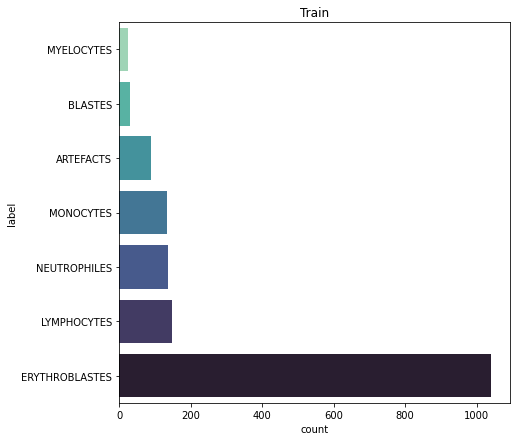

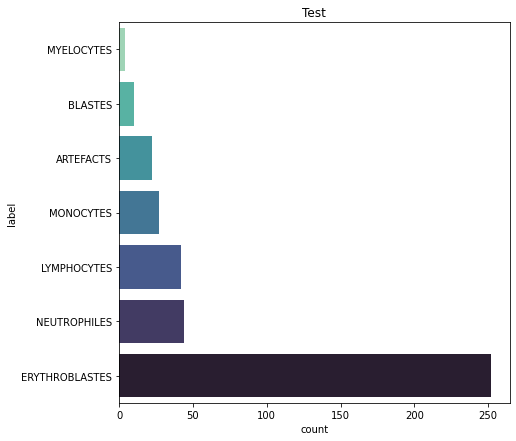

# Rescale data

9) Use *SandardScaler()* to rescale data in X_train.

Remark: the standardscaler is trained on X_train using *fit_transform*, and then applied on X_test using *transform*.

In [98]:
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

# Training model

## SVM model

10) Train a SVM model on the training dataset. Use it to make prediction of the test dataset.


11) Evaluate your performance using *confusion_matrix* and *classification_report*.

You can use *plot_confusion* to visualise the normalised confusion matrix.

*Expected result*


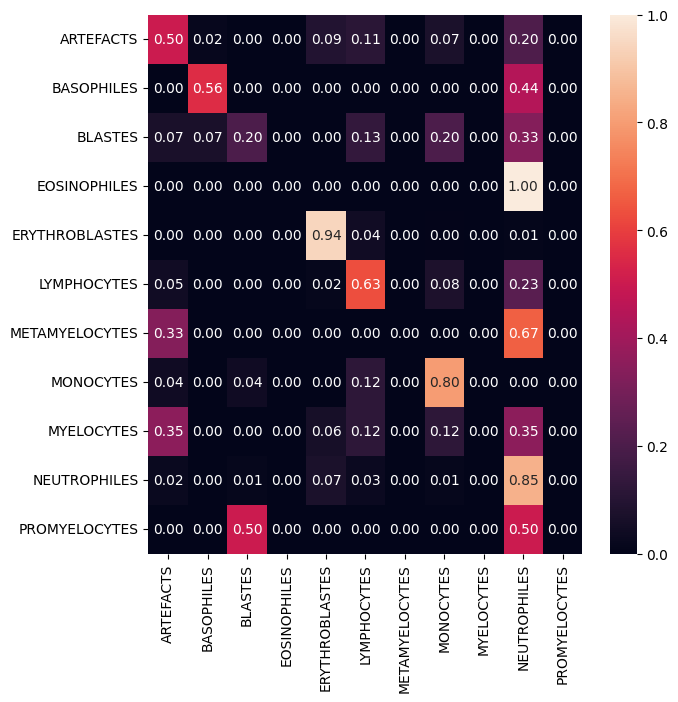

In [74]:
svm_model = svm.SVC(kernel='linear', C = 5)
svm_model.fit(X_train, y_train.values.ravel())
y_pred = svm_model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7893890675241158
                precision    recall  f1-score   support

     ARTEFACTS       0.60      0.50      0.55        54
    BASOPHILES       0.65      0.61      0.63        18
       BLASTES       0.44      0.47      0.45        15
  EOSINOPHILES       1.00      0.50      0.67         2
ERYTHROBLASTES       0.94      0.94      0.94       250
   LYMPHOCYTES       0.68      0.66      0.67        65
METAMYELOCYTES       0.11      0.17      0.13         6
     MONOCYTES       0.51      0.80      0.62        25
    MYELOCYTES       0.43      0.18      0.25        17
  NEUTROPHILES       0.82      0.83      0.83       168
 PROMYELOCYTES       1.00      1.00      1.00         2

      accuracy                           0.79       622
     macro avg       0.65      0.61      0.61       622
  weighted avg       0.79      0.79      0.79       622



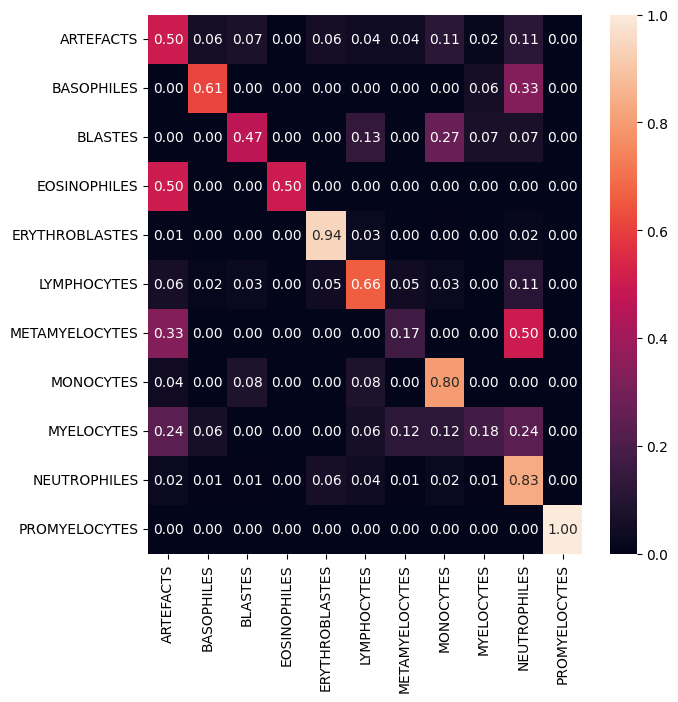

In [75]:
plot_confusion(y_pred, y_test)

## Random Forest
13 )  Repeat 10) and 11) but with RandomForest model

0.770096463022508
                precision    recall  f1-score   support

     ARTEFACTS       0.60      0.50      0.55        54
    BASOPHILES       0.75      0.50      0.60        18
       BLASTES       0.45      0.33      0.38        15
  EOSINOPHILES       0.00      0.00      0.00         2
ERYTHROBLASTES       0.92      0.94      0.93       250
   LYMPHOCYTES       0.58      0.65      0.61        65
METAMYELOCYTES       0.00      0.00      0.00         6
     MONOCYTES       0.48      0.64      0.55        25
    MYELOCYTES       0.27      0.18      0.21        17
  NEUTROPHILES       0.78      0.84      0.81       168
 PROMYELOCYTES       0.00      0.00      0.00         2

      accuracy                           0.77       622
     macro avg       0.44      0.42      0.42       622
  weighted avg       0.75      0.77      0.76       622



/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

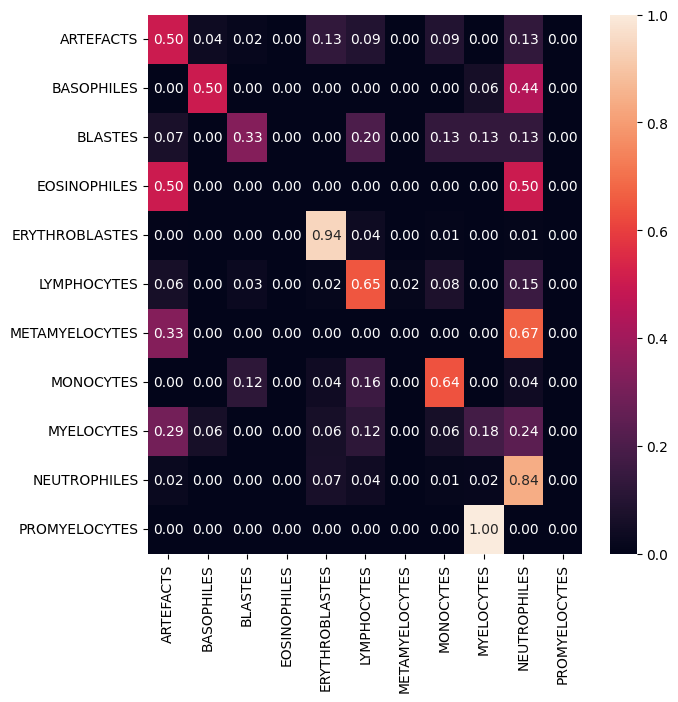

In [76]:
RF_model = RandomForestClassifier(n_estimators=50, random_state=42)
RF_model.fit(X_train, y_train.values.ravel())
y_pred = RF_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
plot_confusion(y_pred, y_test)

## XGBoost

0.77491961414791
              precision    recall  f1-score   support

           0       0.55      0.54      0.54        54
           1       0.71      0.56      0.62        18
           2       0.43      0.40      0.41        15
           3       0.00      0.00      0.00         2
           4       0.93      0.94      0.93       250
           5       0.59      0.55      0.57        65
           6       0.00      0.00      0.00         6
           7       0.61      0.76      0.68        25
           8       0.33      0.24      0.28        17
           9       0.79      0.85      0.82       168
          10       0.00      0.00      0.00         2

    accuracy                           0.77       622
   macro avg       0.45      0.44      0.44       622
weighted avg       0.76      0.77      0.77       622



/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/julienkordes/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

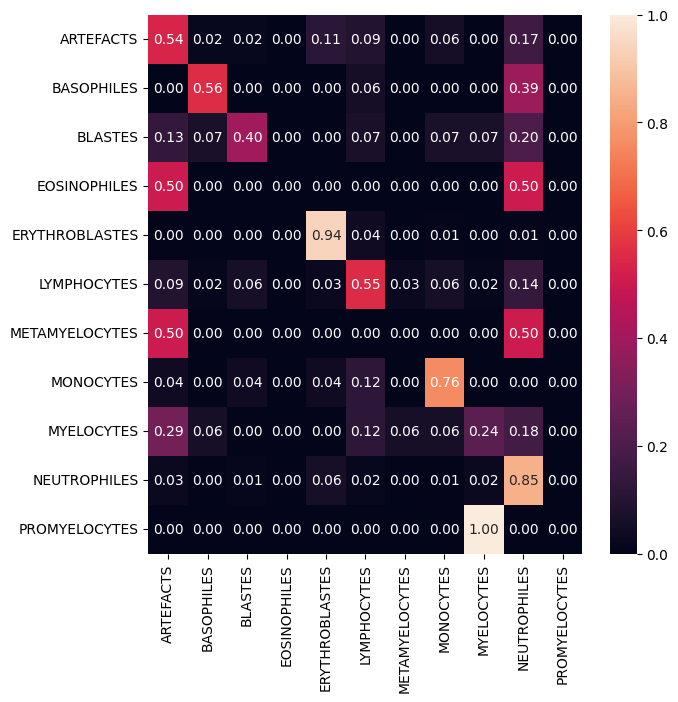

In [77]:
from xgboost import XGBClassifier

XGboost_model = XGBClassifier(n_estimators=100, random_state=42)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train.values.ravel())
y_test_encoded = encoder.transform(y_test.values.ravel())
XGboost_model.fit(X_train, y_train_encoded.ravel())
y_pred = XGboost_model.predict(X_test)
print(accuracy_score(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred))
y_pred = encoder.inverse_transform(y_pred.ravel())
plot_confusion(y_pred, y_test)

# Dimensionality reduction

14) The number of features is important compared with the number of cells. Use dimensionality reduction technique such as PCA to keep only 8 principal components, and evaluate the performance of SVM and RandomForest using only these 8 features. Do you know other dimensionality reduction method and how they work?

In [78]:
n_components = 8
PCA_model = PCA(n_components)
X_train_PCA = PCA_model.fit_transform(X_train)
X_test_PCA = PCA_model.transform(X_test)
explained_variance_ratio = PCA_model.explained_variance_ratio_
print(f"Variance cumulée expliquée par la PCA avec {n_components} composantes principales : {np.cumsum(explained_variance_ratio)[-1]}")

Variance cumulée expliquée par la PCA avec 8 composantes principales : 0.8754322919821131


Accuracy :  0.7315112540192926
Confusion matrix for SVM with PCA :


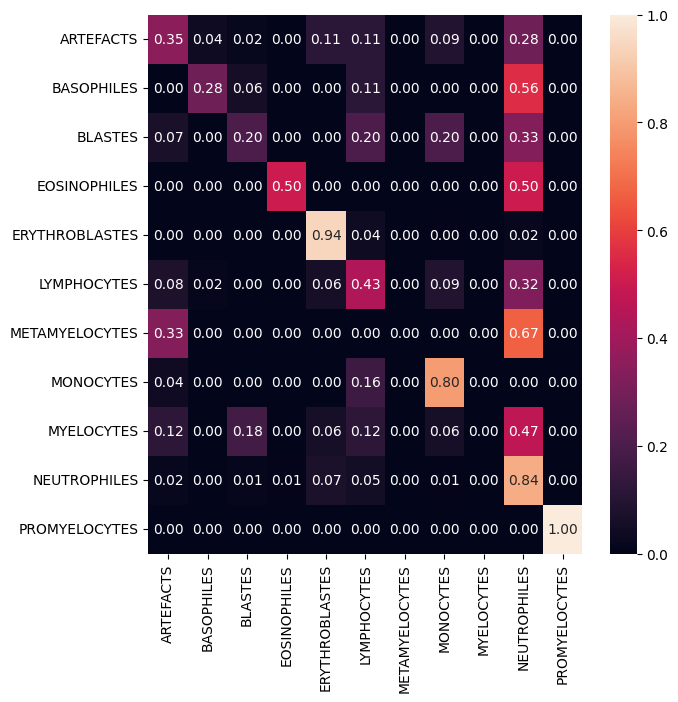

Accuracy :  0.7331189710610932
Confusion matrix for Random Forest with PCA :


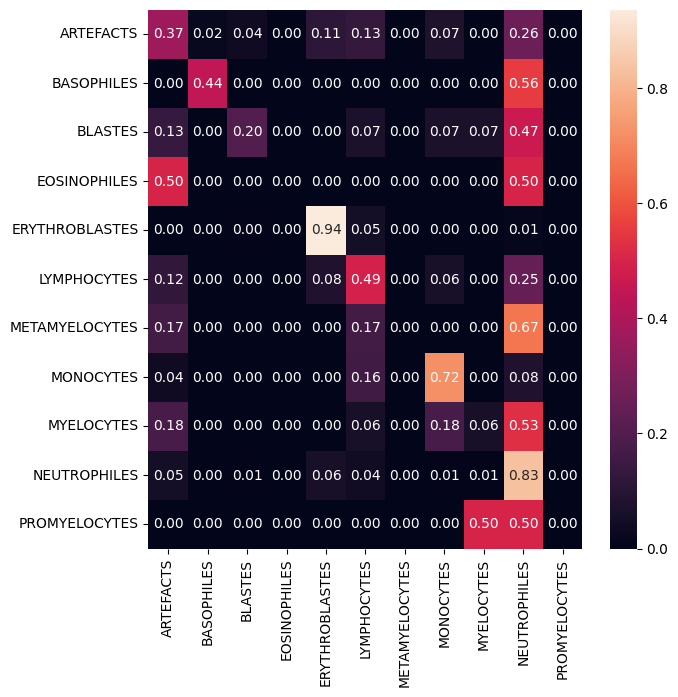

Accuracy :  0.7170418006430869
Confusion matrix for XGBoost with PCA :


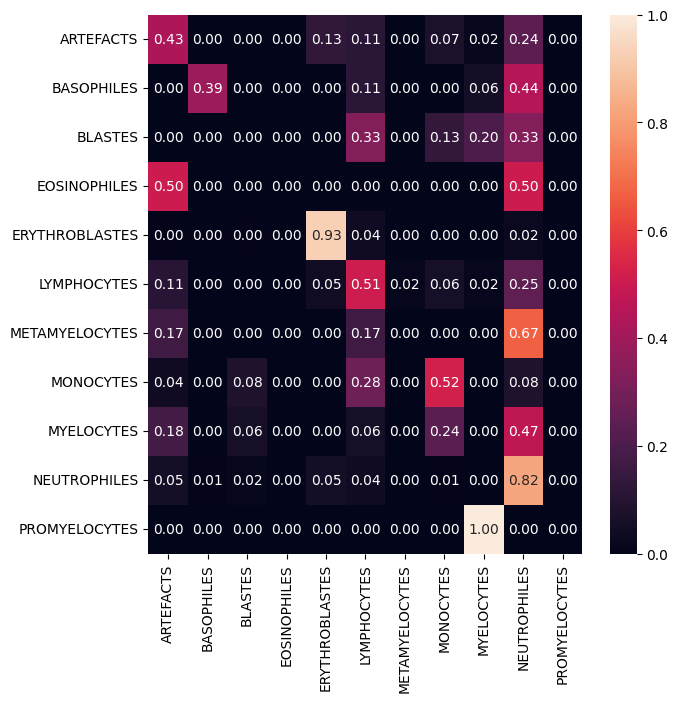

In [79]:
svm_model = svm.SVC(kernel='linear', C=20)
svm_model.fit(X_train_PCA, y_train.values.ravel())
y_pred_PCA = svm_model.predict(X_test_PCA)
print('Accuracy : ', accuracy_score(y_test, y_pred_PCA))
print("Confusion matrix for SVM with PCA :")
plot_confusion(y_pred_PCA, y_test)

RF_model = RandomForestClassifier(n_estimators=50, random_state=42)
RF_model.fit(X_train_PCA, y_train.values.ravel())
y_pred_PCA = RF_model.predict(X_test_PCA)
print('Accuracy : ', accuracy_score(y_test, y_pred_PCA))
print("Confusion matrix for Random Forest with PCA :")
plot_confusion(y_pred_PCA, y_test)

XGboost_model = XGBClassifier(n_estimators=100, random_state=42)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train.values.ravel())
XGboost_model.fit(X_train_PCA, y_train_encoded)
y_test_encoded = encoder.transform(y_test.values.ravel())
y_pred = XGboost_model.predict(X_test_PCA)
print("Accuracy : ", accuracy_score(y_test_encoded, y_pred))
y_pred = encoder.inverse_transform(y_pred.ravel())
print("Confusion matrix for XGBoost with PCA :")
plot_confusion(y_pred, y_test)

# Interpretation of the results

15) Are the results satisfying? Looking at the confusion matrix, what problem(s) are we encountering here?

16) Are there ways to reduce these problems?

As we can see on the confusion matrix, Erythroblastes and Neutrophiles are the class that are the best classified. It can be explained by the fact that they are the 2 most represented class in the dataset. 

Voir SPAM 

# Medical interpretation

17) What are the important features for prediction? How could we interpret results of the model?